In [4]:
# =============================================================================
# DAY 5 — FEATURE SELECTION & TRAIN/TEST SPLIT
# Project: Customer Churn Analytics & Prediction
# =============================================================================
# TASKS:
#   Task 1 — Load churn_cleaned.csv & audit all columns
#   Task 2 — Drop _raw columns + VIF multicollinearity check
#   Task 3 — Correlation heatmap (full feature matrix)
#   Task 4 — Random Forest feature importance (ML preview)
#   Task 5 — Select final feature set, define X and y
#   Task 6 — Stratified train/test split (80/20)
#   Task 7 — Save train/test splits to /data
# =============================================================================
# NEW LIBRARIES NEEDED — run this in your terminal first:
#   pip install scikit-learn statsmodels
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
import warnings

warnings.filterwarnings("ignore")

# ── Plotting style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"      : 130,
    "axes.titlesize"  : 11,
    "axes.labelsize"  : 10,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
    "legend.fontsize" : 9,
})

# Colour palette (consistent with Day 3 & 4)
CLR_RETAIN = "#1D9E75"
CLR_CHURN  = "#E24B4A"
CLR_NEUT   = "#378ADD"
CLR_WARN   = "#F4A83A"
CLR_GREY   = "#9E9E9E"

# ── Paths ──────────────────────────────────────────────────────────────────────
CLEAN_PATH   = "C:/Users/white/Downloads/Learn/Churn_project/data/churn_cleaned.csv"
DATA_DIR     = "C:/Users/white/Downloads/Learn/Churn_project/data"
VISUALS_DIR  = "C:/Users/white/Downloads/Learn/Churn_project/visuals"

os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(VISUALS_DIR, exist_ok=True)

print("=" * 65)
print("  DAY 5 — FEATURE SELECTION & TRAIN/TEST SPLIT")
print("=" * 65)

  DAY 5 — FEATURE SELECTION & TRAIN/TEST SPLIT


In [5]:
# =============================================================================
# TASK 1 — LOAD churn_cleaned.csv & AUDIT ALL COLUMNS
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 1 — Load cleaned dataset & audit columns")
print("=" * 65)

df = pd.read_csv(CLEAN_PATH)

print(f"\n  Loaded : {CLEAN_PATH}")
print(f"  Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Nulls  : {df.isnull().sum().sum()} total")

# ── Categorise every column by type ──────────────────────────────────────────
raw_cols        = [c for c in df.columns if c.endswith("_raw")]
target_col      = ["Churn"]
engineered_cols = ["charge_per_month", "high_value", "num_addons",
                   "tenure_bucket", "mtm_contract"]
ohe_cols        = [c for c in df.columns
                   if any(c.startswith(base + "_") for base in [
                       "MultipleLines", "InternetService", "OnlineSecurity",
                       "OnlineBackup", "DeviceProtection", "TechSupport",
                       "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
                   ])]
base_num_cols   = ["tenure", "MonthlyCharges", "TotalCharges"]
base_bin_cols   = ["gender", "SeniorCitizen", "Partner", "Dependents",
                   "PhoneService", "PaperlessBilling"]

print("\n" + "-" * 65)
print("  COLUMN AUDIT")
print("-" * 65)
print(f"  _raw columns (reference only, drop before ML) : {len(raw_cols)}")
for c in raw_cols:
    print(f"    {c}")
print(f"\n  Target column                                  : {target_col}")
print(f"\n  Engineered features (Day 4)                    : {len(engineered_cols)}")
for c in engineered_cols:
    print(f"    {c}")
print(f"\n  One-hot encoded columns                        : {len(ohe_cols)}")
for c in ohe_cols:
    print(f"    {c}")
print(f"\n  Scaled numerical columns                       : {base_num_cols}")
print(f"  Binary base columns                            : {base_bin_cols}")

print("\n  Task 1 complete ✓")


  TASK 1 — Load cleaned dataset & audit columns

  Loaded : C:/Users/white/Downloads/Learn/Churn_project/data/churn_cleaned.csv
  Shape  : 7,043 rows × 49 columns
  Nulls  : 0 total

-----------------------------------------------------------------
  COLUMN AUDIT
-----------------------------------------------------------------
  _raw columns (reference only, drop before ML) : 3
    tenure_raw
    MonthlyCharges_raw
    TotalCharges_raw

  Target column                                  : ['Churn']

  Engineered features (Day 4)                    : 5
    charge_per_month
    high_value
    num_addons
    tenure_bucket
    mtm_contract

  One-hot encoded columns                        : 31
    MultipleLines_No
    MultipleLines_No phone service
    MultipleLines_Yes
    InternetService_DSL
    InternetService_Fiber optic
    InternetService_No
    OnlineSecurity_No
    OnlineSecurity_No internet service
    OnlineSecurity_Yes
    OnlineBackup_No
    OnlineBackup_No internet service
   

In [6]:
# =============================================================================
# TASK 2 — DROP _raw COLUMNS + VIF MULTICOLLINEARITY CHECK
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 2 — Drop _raw columns + VIF check")
print("=" * 65)

# ── 2a. Drop _raw columns — kept in Day 4 for reference, not needed for ML ───
df.drop(columns=raw_cols, inplace=True)
print(f"\n  Dropped {len(raw_cols)} _raw columns")
print(f"  Shape after drop : {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── 2b. VIF check on numerical + engineered features ─────────────────────────
# VIF (Variance Inflation Factor) measures multicollinearity.
# Rule of thumb:  VIF < 5  = fine | 5–10 = moderate | > 10 = drop candidate
print("\n" + "-" * 65)
print("  VIF — VARIANCE INFLATION FACTOR")
print("  (measures multicollinearity — VIF > 10 → consider dropping)")
print("-" * 65)

vif_cols = base_num_cols + engineered_cols
vif_df_input = df[vif_cols].copy()

vif_results = pd.DataFrame({
    "Feature" : vif_cols,
    "VIF"     : [
        variance_inflation_factor(vif_df_input.values, i)
        for i in range(vif_df_input.shape[1])
    ]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(f"\n  {'Feature':<25} {'VIF':>8}  {'Status'}")
print(f"  {'-'*25} {'-'*8}  {'-'*20}")
for _, row in vif_results.iterrows():
    if row["VIF"] > 10:
        status = "⚠  HIGH — drop candidate"
        clr_tag = ""
    elif row["VIF"] > 5:
        status = "△  MODERATE — monitor"
        clr_tag = ""
    else:
        status = "✓  OK"
        clr_tag = ""
    print(f"  {row['Feature']:<25} {row['VIF']:>8.2f}  {status}")

# ── 2c. Drop TotalCharges if VIF > 10 ────────────────────────────────────────
tc_vif = vif_results.loc[vif_results["Feature"] == "TotalCharges", "VIF"].values[0]
print("\n" + "-" * 65)
if tc_vif > 10:
    df.drop(columns=["TotalCharges"], inplace=True)
    print(f"  TotalCharges dropped  (VIF = {tc_vif:.1f} > 10)")
    print("  Reason: TotalCharges = tenure × MonthlyCharges — redundant info")
    print("  tenure and MonthlyCharges are both retained")
else:
    print(f"  TotalCharges retained (VIF = {tc_vif:.1f} ≤ 10)")

# ── 2d. Similarly check charge_per_month (derived from TotalCharges) ─────────
cp_vif = vif_results.loc[vif_results["Feature"] == "charge_per_month", "VIF"].values[0]
if cp_vif > 10:
    df.drop(columns=["charge_per_month"], inplace=True)
    print(f"  charge_per_month dropped (VIF = {cp_vif:.1f} > 10)")
else:
    print(f"  charge_per_month retained (VIF = {cp_vif:.1f} ≤ 10)")

print(f"\n  Shape after VIF cleanup : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n  Task 2 complete ✓")


  TASK 2 — Drop _raw columns + VIF check

  Dropped 3 _raw columns
  Shape after drop : 7,043 rows × 46 columns

-----------------------------------------------------------------
  VIF — VARIANCE INFLATION FACTOR
  (measures multicollinearity — VIF > 10 → consider dropping)
-----------------------------------------------------------------

  Feature                        VIF  Status
  ------------------------- --------  --------------------
  charge_per_month            156.74  ⚠  HIGH — drop candidate
  MonthlyCharges              134.64  ⚠  HIGH — drop candidate
  tenure                       38.34  ⚠  HIGH — drop candidate
  tenure_bucket                20.81  ⚠  HIGH — drop candidate
  TotalCharges                 20.23  ⚠  HIGH — drop candidate
  num_addons                    6.81  △  MODERATE — monitor
  mtm_contract                  4.13  ✓  OK
  high_value                    2.81  ✓  OK

-----------------------------------------------------------------
  TotalCharges dropped 


  TASK 3 — Correlation heatmap (full feature matrix)


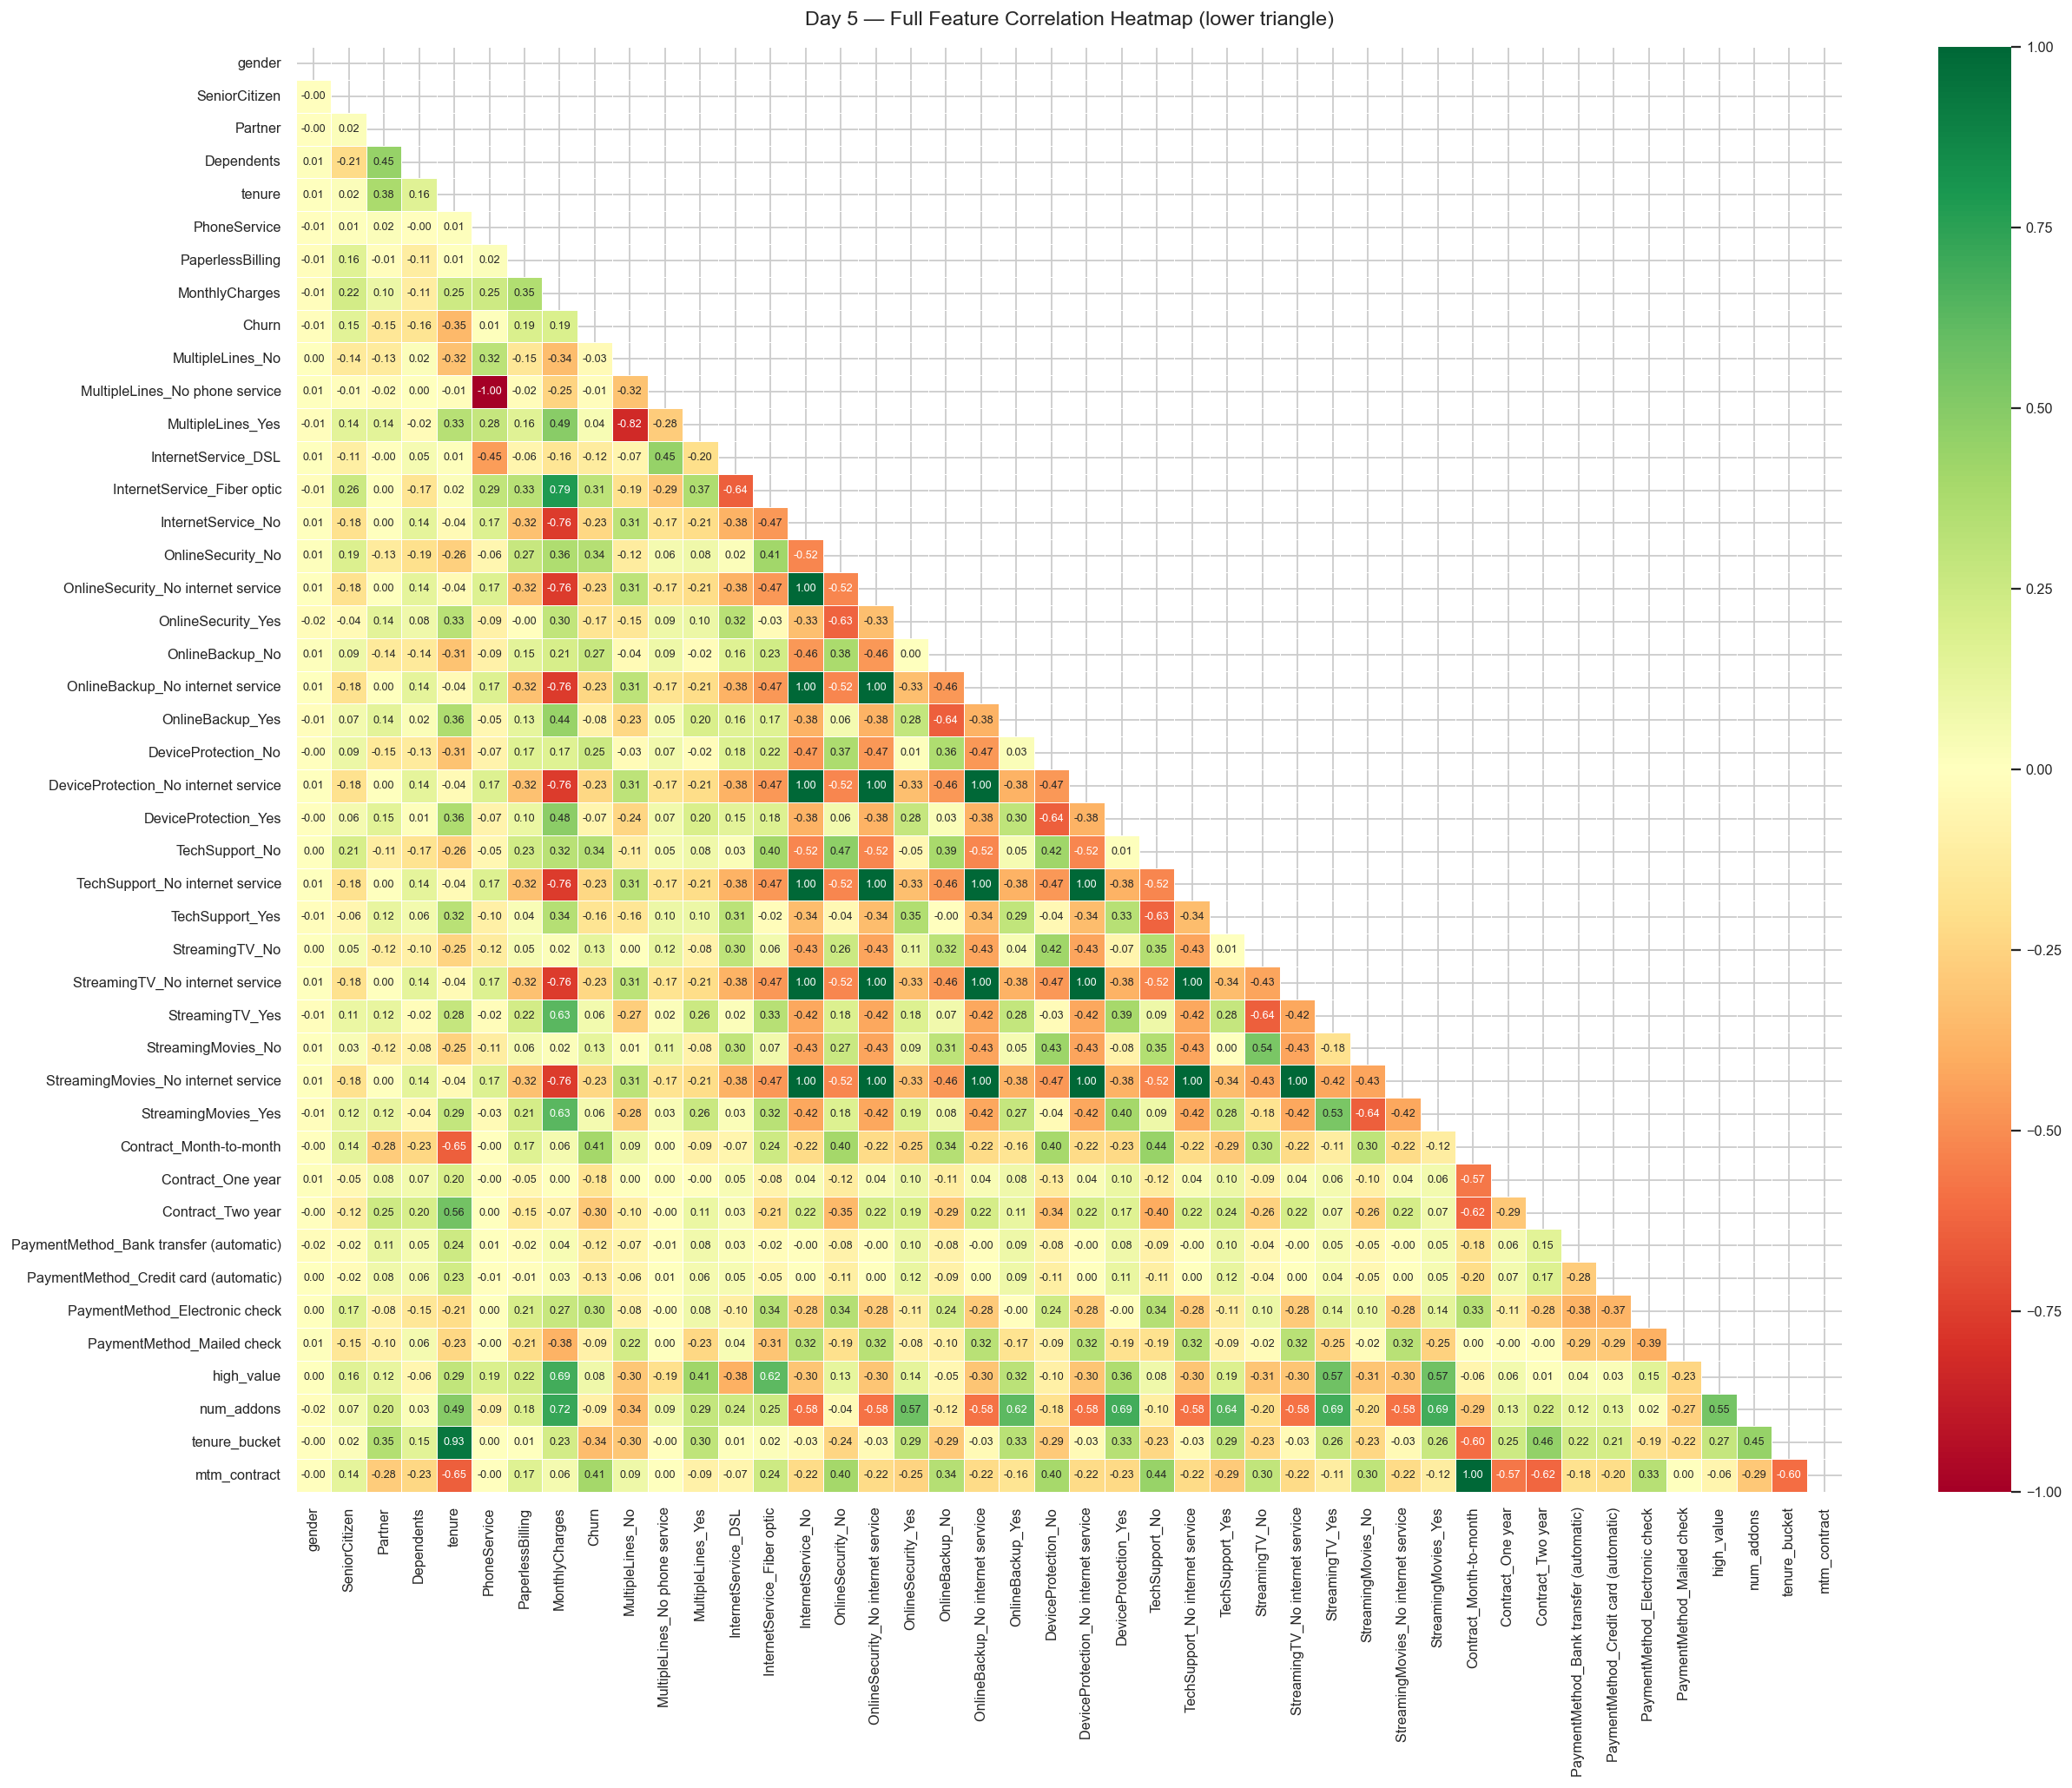

  Chart saved: day5_correlation_heatmap_full.png

-----------------------------------------------------------------
  TOP CORRELATIONS WITH CHURN (sorted by absolute value)
-----------------------------------------------------------------

  Rank  Feature                                   r   Direction
  ----- ----------------------------------- -------   ------------------------------
  1     mtm_contract                        +0.405   ↑ higher → more churn
  2     Contract_Month-to-month             +0.405   ↑ higher → more churn
  3     tenure                              -0.352   ↓ lower  → more churn
  4     OnlineSecurity_No                   +0.343   ↑ higher → more churn
  5     tenure_bucket                       -0.339   ↓ lower  → more churn
  6     TechSupport_No                      +0.337   ↑ higher → more churn
  7     InternetService_Fiber optic         +0.308   ↑ higher → more churn
  8     Contract_Two year                   -0.302   ↓ lower  → more churn
  9     Pay

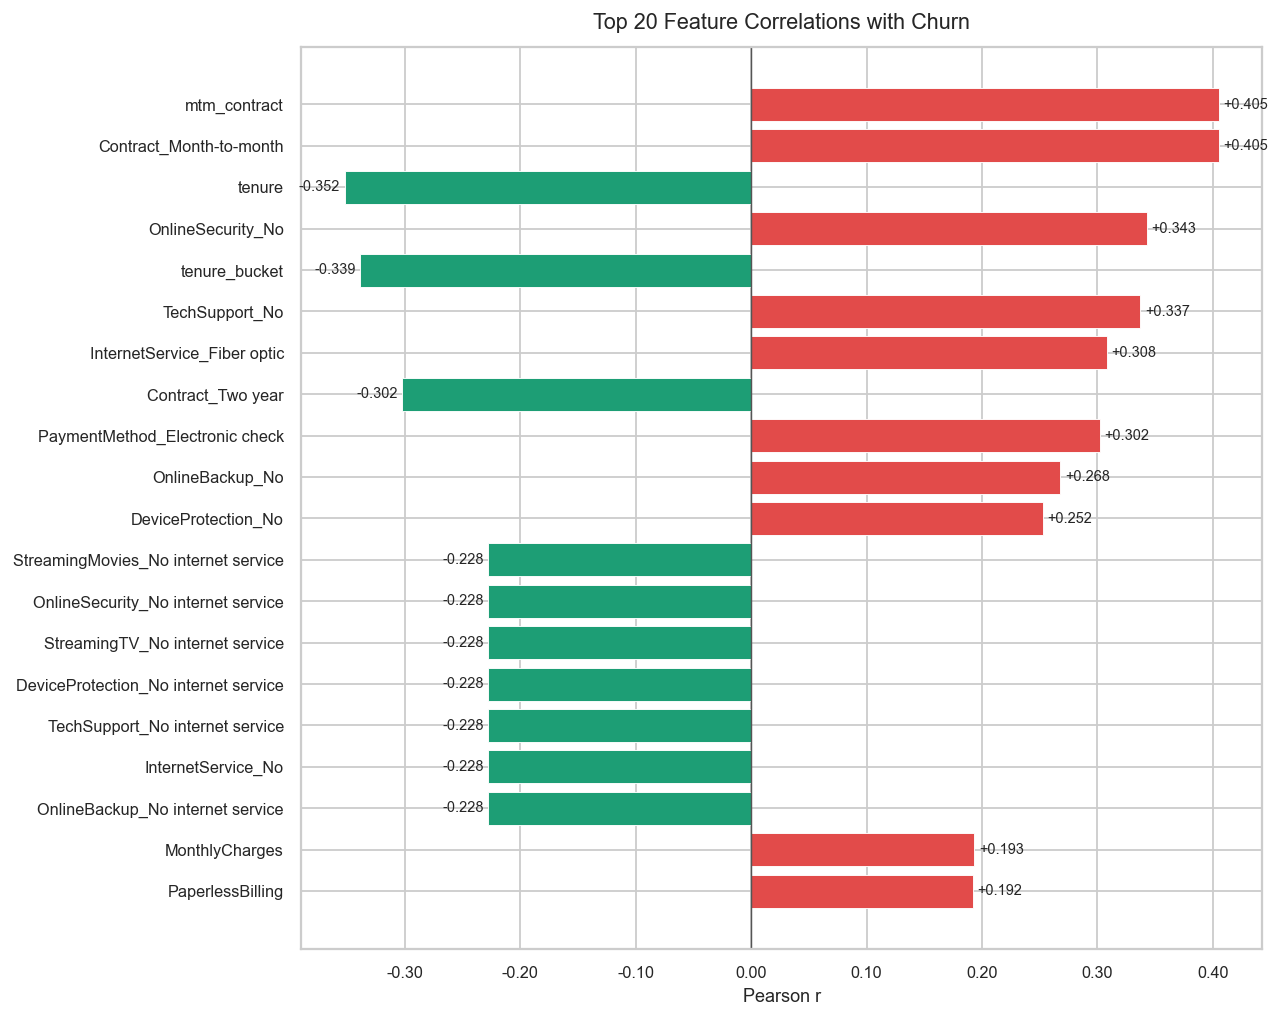

  Chart saved: day5_churn_correlations.png

  Task 3 complete ✓


In [7]:
# =============================================================================
# TASK 3 — CORRELATION HEATMAP (FULL FEATURE MATRIX)
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 3 — Correlation heatmap (full feature matrix)")
print("=" * 65)

# Use all remaining numeric columns (everything is now numeric post-Day 4)
corr_matrix = df.corr(numeric_only=True)

# ── 3a. Full heatmap ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt=".2f", linewidths=0.3,
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    annot_kws={"size": 7}, ax=ax
)
ax.set_title("Day 5 — Full Feature Correlation Heatmap (lower triangle)", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day5_correlation_heatmap_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day5_correlation_heatmap_full.png")

# ── 3b. Top correlations with Churn ──────────────────────────────────────────
print("\n" + "-" * 65)
print("  TOP CORRELATIONS WITH CHURN (sorted by absolute value)")
print("-" * 65)

churn_corr = (
    corr_matrix["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
    .head(20)
)

print(f"\n  {'Rank':<5} {'Feature':<35} {'r':>7}   {'Direction'}")
print(f"  {'-'*5} {'-'*35} {'-'*7}   {'-'*30}")
for rank, (feat, val) in enumerate(churn_corr.items(), 1):
    direction = "↑ higher → more churn" if val > 0 else "↓ lower  → more churn"
    bar = ("▮" if val > 0 else "▯") * int(abs(val) * 20)
    print(f"  {rank:<5} {feat:<35} {val:>+.3f}   {direction}")

# ── 3c. Churn correlation bar chart (top 20) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors = [CLR_CHURN if v > 0 else CLR_RETAIN for v in churn_corr.values]
ax.barh(churn_corr.index[::-1], churn_corr.values[::-1], color=colors[::-1],
        edgecolor="white", linewidth=0.5)
ax.axvline(0, color="#555", linewidth=0.8)
ax.set_title("Top 20 Feature Correlations with Churn", fontsize=12, pad=10)
ax.set_xlabel("Pearson r")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
for i, (val, label) in enumerate(zip(churn_corr.values[::-1], churn_corr.index[::-1])):
    offset = 0.004 if val >= 0 else -0.004
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, i, f"{val:+.3f}", va="center", ha=ha, fontsize=8)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day5_churn_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day5_churn_correlations.png")
print("\n  Task 3 complete ✓")


  TASK 4 — Random Forest feature importance (ML preview)

  Why do this now?
  ─────────────────
  Correlation measures LINEAR relationships only.
  Random Forest feature importance captures NON-LINEAR patterns too.
  Running it here gives us a preview of which features the full model
  (Day 8) will likely rely on most — so we can drop noise early.

  Random Forest fitted ✓  (n_estimators=200, max_depth=10, balanced)

-----------------------------------------------------------------
  Rank  Feature                                  Importance
  ----- -------------------------------------- ------------
  1     tenure                                       0.1233  ▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
  2     Contract_Month-to-month                      0.1105  ▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
  3     mtm_contract                                 0.0999  ▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
  4     MonthlyCharges                               0.0932  ▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮▮
  5     tenure_buc

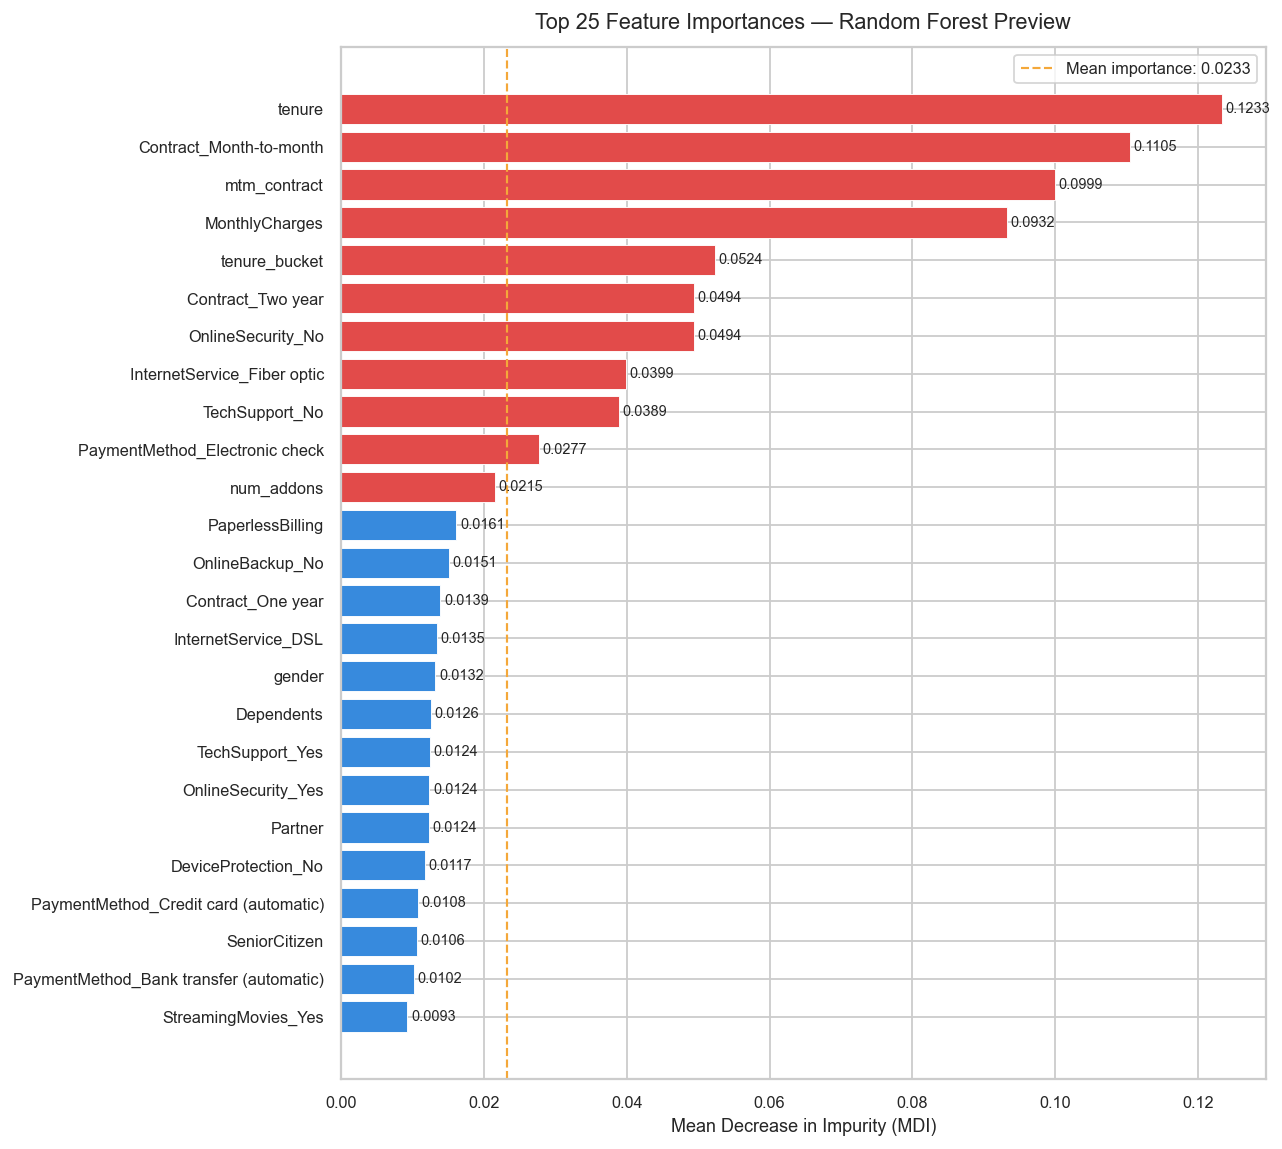


  Chart saved: day5_rf_feature_importance.png

-----------------------------------------------------------------
  LOW IMPORTANCE FEATURES (importance < 0.005)
  These add noise — will be dropped from the final feature set
-----------------------------------------------------------------
  StreamingMovies_No internet service    0.0047
  MultipleLines_No phone service         0.0040
  StreamingTV_No internet service        0.0037
  PhoneService                           0.0035

  Task 4 complete ✓


In [8]:
# =============================================================================
# TASK 4 — RANDOM FOREST FEATURE IMPORTANCE (ML PREVIEW)
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 4 — Random Forest feature importance (ML preview)")
print("=" * 65)
print("""
  Why do this now?
  ─────────────────
  Correlation measures LINEAR relationships only.
  Random Forest feature importance captures NON-LINEAR patterns too.
  Running it here gives us a preview of which features the full model
  (Day 8) will likely rely on most — so we can drop noise early.
""")

# ── 4a. Prepare X and y for the RF run ───────────────────────────────────────
X_rf = df.drop(columns=["Churn"])
y_rf = df["Churn"]

# Quick RF — not tuned, just for importance ranking
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"    # handles class imbalance (26.5% churn)
)
rf_model.fit(X_rf, y_rf)
print("  Random Forest fitted ✓  (n_estimators=200, max_depth=10, balanced)")

# ── 4b. Importance DataFrame ──────────────────────────────────────────────────
importance_df = (
    pd.DataFrame({
        "Feature"    : X_rf.columns,
        "Importance" : rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "-" * 65)
print(f"  {'Rank':<5} {'Feature':<38} {'Importance':>12}")
print(f"  {'-'*5} {'-'*38} {'-'*12}")
for i, row in importance_df.iterrows():
    bar = "▮" * int(row["Importance"] * 300)
    print(f"  {i+1:<5} {row['Feature']:<38} {row['Importance']:>12.4f}  {bar}")

# ── 4c. Feature importance chart (top 25) ────────────────────────────────────
top_n = 25
top_imp = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 9))
bar_colors = [CLR_CHURN if imp >= importance_df["Importance"].quantile(0.75) else CLR_NEUT
              for imp in top_imp["Importance"]]
ax.barh(top_imp["Feature"][::-1], top_imp["Importance"][::-1],
        color=bar_colors[::-1], edgecolor="white", linewidth=0.5)
ax.set_title(f"Top {top_n} Feature Importances — Random Forest Preview", fontsize=12, pad=10)
ax.set_xlabel("Mean Decrease in Impurity (MDI)")
ax.axvline(importance_df["Importance"].mean(), color=CLR_WARN, lw=1.2, ls="--",
           label=f"Mean importance: {importance_df['Importance'].mean():.4f}")
for i, (val, label) in enumerate(zip(top_imp["Importance"][::-1], top_imp["Feature"][::-1])):
    ax.text(val + 0.0005, i, f"{val:.4f}", va="center", fontsize=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day5_rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: day5_rf_feature_importance.png")

# ── 4d. Low importance features (candidates to drop) ─────────────────────────
importance_threshold = 0.005
low_importance = importance_df[importance_df["Importance"] < importance_threshold]
print("\n" + "-" * 65)
print(f"  LOW IMPORTANCE FEATURES (importance < {importance_threshold})")
print(f"  These add noise — will be dropped from the final feature set")
print("-" * 65)
for _, row in low_importance.iterrows():
    print(f"  {row['Feature']:<38} {row['Importance']:.4f}")

print("\n  Task 4 complete ✓")

In [9]:
# =============================================================================
# TASK 5 — SELECT FINAL FEATURE SET, DEFINE X AND y
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 5 — Select final feature set")
print("=" * 65)

# ── 5a. Drop low-importance features ─────────────────────────────────────────
low_imp_cols = low_importance["Feature"].tolist()
df_final = df.drop(columns=low_imp_cols)
print(f"\n  Dropped {len(low_imp_cols)} low-importance features:")
for c in low_imp_cols:
    print(f"    {c}")

# ── 5b. Define X (features) and y (target) ────────────────────────────────────
X = df_final.drop(columns=["Churn"])
y = df_final["Churn"]

print(f"\n  X shape : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"  y shape : {y.shape[0]:,} rows")
print(f"  y distribution:")
print(f"    Retained (0) : {(y == 0).sum():,}  ({(y == 0).mean()*100:.1f}%)")
print(f"    Churned  (1) : {(y == 1).sum():,}  ({(y == 1).mean()*100:.1f}%)")

# ── 5c. Final feature list ────────────────────────────────────────────────────
print("\n" + "-" * 65)
print("  FINAL FEATURE LIST (fed into ML model on Day 8)")
print("-" * 65)
for i, col in enumerate(X.columns, 1):
    imp_val = importance_df.loc[importance_df["Feature"] == col, "Importance"]
    imp_str = f"  [RF imp: {imp_val.values[0]:.4f}]" if len(imp_val) > 0 else ""
    print(f"  {i:>3}. {col:<38}{imp_str}")

print("\n  Task 5 complete ✓")


  TASK 5 — Select final feature set

  Dropped 4 low-importance features:
    StreamingMovies_No internet service
    MultipleLines_No phone service
    StreamingTV_No internet service
    PhoneService

  X shape : 7,043 rows × 39 features
  y shape : 7,043 rows
  y distribution:
    Retained (0) : 5,174  (73.5%)
    Churned  (1) : 1,869  (26.5%)

-----------------------------------------------------------------
  FINAL FEATURE LIST (fed into ML model on Day 8)
-----------------------------------------------------------------
    1. gender                                  [RF imp: 0.0132]
    2. SeniorCitizen                           [RF imp: 0.0106]
    3. Partner                                 [RF imp: 0.0124]
    4. Dependents                              [RF imp: 0.0126]
    5. tenure                                  [RF imp: 0.1233]
    6. PaperlessBilling                        [RF imp: 0.0161]
    7. MonthlyCharges                          [RF imp: 0.0932]
    8. MultipleLine


  TASK 6 — Stratified train/test split (80/20)

  Why stratified?
  ────────────────
  Our dataset has class imbalance (26.5% churn).
  A regular random split might put most churned customers into train
  and leave very few in test — making evaluation unreliable.
  Stratified split guarantees the 26.5% churn ratio is preserved
  in BOTH train and test sets.

  X_train : 5,634 rows × 39 features
  X_test  : 1,409 rows × 39 features

  Churn distribution after split:
  Split          Retained      Churned
  ---------- ------------ ------------
  Train        4,139 (73.5%)     1,495 (26.5%)
  Test         1,035 (73.5%)       374 (26.5%)


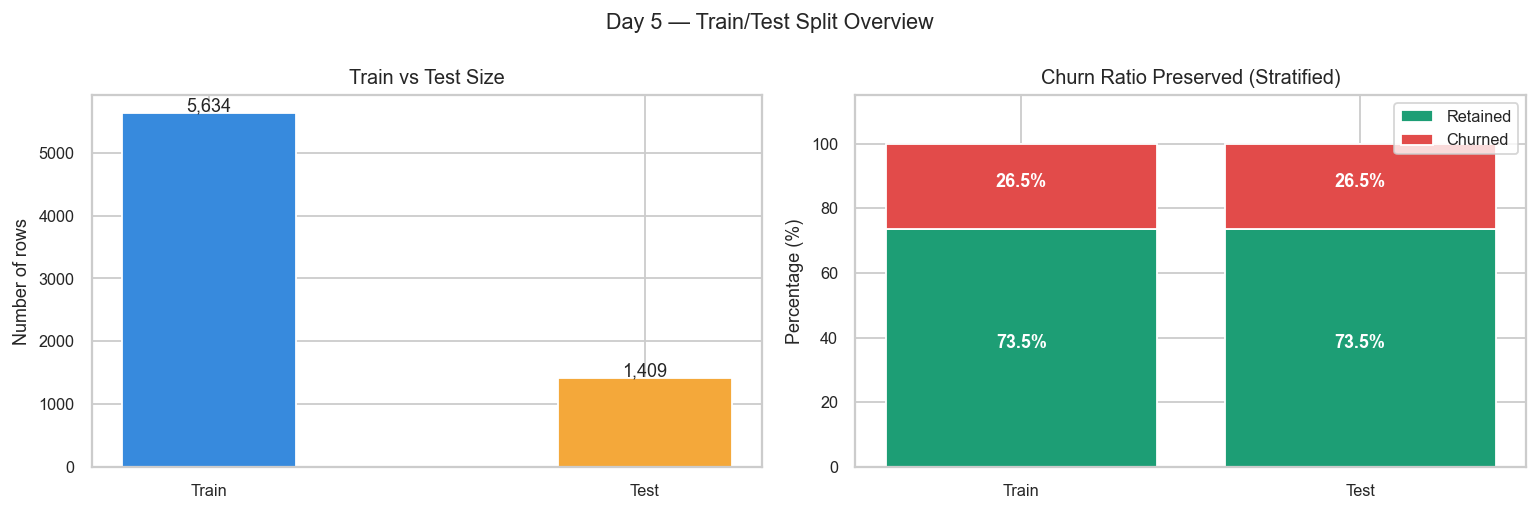

  Chart saved: day5_train_test_split.png

  Task 6 complete ✓


In [10]:
# =============================================================================
# TASK 6 — STRATIFIED TRAIN/TEST SPLIT (80/20)
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 6 — Stratified train/test split (80/20)")
print("=" * 65)
print("""
  Why stratified?
  ────────────────
  Our dataset has class imbalance (26.5% churn).
  A regular random split might put most churned customers into train
  and leave very few in test — making evaluation unreliable.
  Stratified split guarantees the 26.5% churn ratio is preserved
  in BOTH train and test sets.
""")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y      # ← preserves churn ratio in both splits
)

print(f"  X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"  X_test  : {X_test.shape[0]:,} rows × {X_test.shape[1]} features")
print(f"\n  Churn distribution after split:")
print(f"  {'Split':<10} {'Retained':>12} {'Churned':>12}")
print(f"  {'-'*10} {'-'*12} {'-'*12}")
for split_name, y_split in [("Train", y_train), ("Test", y_test)]:
    n_ret = (y_split == 0).sum()
    n_churn = (y_split == 1).sum()
    print(f"  {split_name:<10} {n_ret:>7,} ({n_ret/len(y_split)*100:.1f}%)   "
          f"{n_churn:>7,} ({n_churn/len(y_split)*100:.1f}%)")

# ── 6a. Split visualisation ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Day 5 — Train/Test Split Overview", fontsize=12)

# Bar chart: split sizes
split_labels = ["Train", "Test"]
split_sizes  = [len(X_train), len(X_test)]
split_colors = [CLR_NEUT, CLR_WARN]
axes[0].bar(split_labels, split_sizes, color=split_colors, edgecolor="white", width=0.4)
axes[0].set_title("Train vs Test Size", fontsize=11)
axes[0].set_ylabel("Number of rows")
for i, v in enumerate(split_sizes):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=10)

# Stacked bar: churn ratio per split
train_ret   = (y_train == 0).sum() / len(y_train) * 100
train_churn = (y_train == 1).sum() / len(y_train) * 100
test_ret    = (y_test == 0).sum()  / len(y_test)  * 100
test_churn  = (y_test == 1).sum()  / len(y_test)  * 100

axes[1].bar(["Train", "Test"], [train_ret, test_ret],   color=CLR_RETAIN, label="Retained", edgecolor="white")
axes[1].bar(["Train", "Test"], [train_churn, test_churn], bottom=[train_ret, test_ret],
            color=CLR_CHURN, label="Churned", edgecolor="white")
axes[1].set_title("Churn Ratio Preserved (Stratified)", fontsize=11)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 115)
axes[1].legend(loc="upper right")
for i, (ret, churn) in enumerate([(train_ret, train_churn), (test_ret, test_churn)]):
    axes[1].text(i, ret / 2, f"{ret:.1f}%", ha="center", fontsize=10, color="white", fontweight="bold")
    axes[1].text(i, ret + churn / 2, f"{churn:.1f}%", ha="center", fontsize=10, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/day5_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: day5_train_test_split.png")
print("\n  Task 6 complete ✓")

In [11]:
# =============================================================================
# TASK 7 — SAVE TRAIN/TEST SPLITS TO /data
# =============================================================================
print("\n" + "=" * 65)
print("  TASK 7 — Save train/test splits")
print("=" * 65)

# Combine X + y for each split into a single DataFrame for easy loading
train_df = X_train.copy()
train_df["Churn"] = y_train.values

test_df = X_test.copy()
test_df["Churn"] = y_test.values

# Save paths
TRAIN_PATH   = f"{DATA_DIR}/train.csv"
TEST_PATH    = f"{DATA_DIR}/test.csv"
X_TRAIN_PATH = f"{DATA_DIR}/X_train.csv"
X_TEST_PATH  = f"{DATA_DIR}/X_test.csv"
Y_TRAIN_PATH = f"{DATA_DIR}/y_train.csv"
Y_TEST_PATH  = f"{DATA_DIR}/y_test.csv"

# Full split files (combined)
train_df.to_csv(TRAIN_PATH,   index=False)
test_df.to_csv(TEST_PATH,    index=False)

# Separate X / y files (for direct use in sklearn on Day 8)
X_train.to_csv(X_TRAIN_PATH, index=False)
X_test.to_csv(X_TEST_PATH,  index=False)
y_train.to_csv(Y_TRAIN_PATH, index=False, header=True)
y_test.to_csv(Y_TEST_PATH,  index=False, header=True)

print(f"\n  Saved → {TRAIN_PATH}   ({train_df.shape[0]:,} rows × {train_df.shape[1]} cols)")
print(f"  Saved → {TEST_PATH}    ({test_df.shape[0]:,}  rows × {test_df.shape[1]} cols)")
print(f"  Saved → {X_TRAIN_PATH} ({X_train.shape[0]:,} rows × {X_train.shape[1]} cols)")
print(f"  Saved → {X_TEST_PATH}  ({X_test.shape[0]:,}  rows × {X_test.shape[1]} cols)")
print(f"  Saved → {Y_TRAIN_PATH} ({y_train.shape[0]:,} rows)")
print(f"  Saved → {Y_TEST_PATH}  ({y_test.shape[0]:,}  rows)")

# ── Quick verification read-back ──────────────────────────────────────────────
verify_train = pd.read_csv(TRAIN_PATH)
verify_test  = pd.read_csv(TEST_PATH)
print(f"\n  Verification:")
print(f"  train.csv read back : {verify_train.shape[0]:,} rows × {verify_train.shape[1]} cols  ✓")
print(f"  test.csv  read back : {verify_test.shape[0]:,}  rows × {verify_test.shape[1]} cols  ✓")
print("\n  Task 7 complete ✓")


  TASK 7 — Save train/test splits

  Saved → C:/Users/white/Downloads/Learn/Churn_project/data/train.csv   (5,634 rows × 40 cols)
  Saved → C:/Users/white/Downloads/Learn/Churn_project/data/test.csv    (1,409  rows × 40 cols)
  Saved → C:/Users/white/Downloads/Learn/Churn_project/data/X_train.csv (5,634 rows × 39 cols)
  Saved → C:/Users/white/Downloads/Learn/Churn_project/data/X_test.csv  (1,409  rows × 39 cols)
  Saved → C:/Users/white/Downloads/Learn/Churn_project/data/y_train.csv (5,634 rows)
  Saved → C:/Users/white/Downloads/Learn/Churn_project/data/y_test.csv  (1,409  rows)

  Verification:
  train.csv read back : 5,634 rows × 40 cols  ✓
  test.csv  read back : 1,409  rows × 40 cols  ✓

  Task 7 complete ✓


In [12]:
# ── DAY 5 SUMMARY ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  DAY 5 COMPLETE — KEY FINDINGS")
print("=" * 65)
print(f"  Final feature count     : {X.shape[1]} features  (after VIF + importance filter)")
print(f"  Low-importance dropped  : {len(low_imp_cols)} features")
print(f"  Multicollinear dropped  : TotalCharges (VIF > 10)")
print(f"  Train set size          : {X_train.shape[0]:,} rows")
print(f"  Test set size           : {X_test.shape[0]:,} rows")
print(f"  Churn ratio preserved   : ~26.5% in both splits (stratified)")
print(f"  Top 3 RF features       : {', '.join(importance_df['Feature'].head(3).tolist())}")
print(f"  Files saved to /data    : train.csv, test.csv, X_train/test, y_train/test")
print(f"  Charts saved            : 4 charts in /visuals/")
print("")
print("  TOMORROW — Day 6:")
print("  -> Build baseline models (Logistic Regression, Decision Tree)")
print("  -> Evaluate with accuracy, precision, recall, F1, ROC-AUC")
print("  -> Confusion matrix analysis")
print("  -> Understand why accuracy alone is misleading for imbalanced data")
print("=" * 65)


  DAY 5 COMPLETE — KEY FINDINGS
  Final feature count     : 39 features  (after VIF + importance filter)
  Low-importance dropped  : 4 features
  Multicollinear dropped  : TotalCharges (VIF > 10)
  Train set size          : 5,634 rows
  Test set size           : 1,409 rows
  Churn ratio preserved   : ~26.5% in both splits (stratified)
  Top 3 RF features       : tenure, Contract_Month-to-month, mtm_contract
  Files saved to /data    : train.csv, test.csv, X_train/test, y_train/test
  Charts saved            : 4 charts in /visuals/

  TOMORROW — Day 6:
  -> Build baseline models (Logistic Regression, Decision Tree)
  -> Evaluate with accuracy, precision, recall, F1, ROC-AUC
  -> Confusion matrix analysis
  -> Understand why accuracy alone is misleading for imbalanced data
